# Reproduce-then-Extend — Civil-War Onset (Fearon & Laitin 2003)  ·  **Day 1 tutorial**

> **Published study.** Fearon, J. D. & Laitin, D. D. (2003). "Ethnicity, Insurgency, and Civil War."
> *American Political Science Review* 97(1):75–90. A **logistic regression** of civil-war onset on 11
> country-year predictors (Sambanis 2006 imputed data; Harvard Dataverse doi:10.7910/DVN/KRKWK8). Onset is a
> **rare event** (~1.6%); this example illustrates **out-of-sample classification** and the right evaluation
> metric for imbalanced data.

## Background

Fearon and Laitin ask **what conditions make civil war likely** worldwide from 1945 to 1999. Their central aim is to adjudicate between two explanations: civil war as a product of ethnic and religious **grievance**, versus civil war as a product of conditions that favor **insurgency** -- weak states, poverty, rough terrain, and populations governments cannot control. They use **logistic regression** of civil-war onset on structural covariates to test which set of factors predicts onset. The **primary conclusion** is that insurgency-favoring conditions (low GDP per capita, large population, mountainous terrain, political instability, new states) strongly predict civil war, while ethnic and religious fractionalization do **not** -- a direct challenge to the ethnic-grievance thesis.

## Data and codebook

**Unit of analysis:** country-year; n = 7,140 (116 civil-war onsets, ~1.6%).

| Variable | Definition |
|---|---|
| `warstds` | civil-war onset: 1 in the first year of a new civil war **(outcome)** |
| `warhist` | prior civil-war history in the country |
| `ln_gdpen` | log GDP per capita (lagged one year) |
| `lpopns` | log national population |
| `lmtnest` | log % of the country that is mountainous terrain |
| `ncontig` | 1 if the state has noncontiguous territory |
| `oil` | 1 if fuel exports exceed one-third of total exports (oil exporter) |
| `nwstate` | 1 in the first two years of a newly independent state |
| `inst3` | political instability: a >=3-point Polity change in the prior 3 years |
| `pol4` | Polity score (-10 autocracy to +10 democracy) |
| `ef` | ethnolinguistic fractionalization |
| `relfrac` | religious fractionalization |

## Descriptive results

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

In [2]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/SambnisImp.csv')
fl = ['warhist','ln_gdpen','lpopns','lmtnest','ncontig','oil','nwstate','inst3','pol4','ef','relfrac']
d = d[['warstds'] + fl].dropna()
d.describe().T[['mean','std','min','max']].round(2)

,mean,std,min,max
warstds,0.02,0.13,0.00,1.00
warhist,0.17,0.38,0.00,1.00
ln_gdpen,0.76,1.00,-3.04,4.07
lpopns,15.75,1.63,11.01,20.95
lmtnest,2.18,1.34,0.00,4.56
ncontig,0.18,0.36,0.00,1.00
oil,0.12,0.32,0.00,1.00
nwstate,0.03,0.16,0.00,1.00
inst3,0.15,0.34,0.00,1.00
pol4,-0.10,7.26,-10.00,10.00


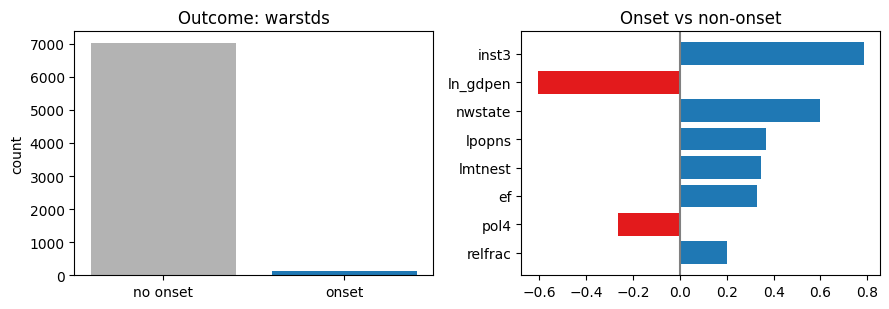

In [3]:
y = d['warstds'].values
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(['no onset','onset'], np.bincount(y), color=['0.7','#1f78b4']); ax[0].set_title('Outcome: warstds'); ax[0].set_ylabel('count')
smd = pd.Series({c: (d[c][y==1].mean()-d[c][y==0].mean())/d[c].std() for c in fl})
smd = smd.reindex(smd.abs().sort_values().index)[-8:]
ax[1].barh(smd.index, smd.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in smd])
ax[1].set_title('Onset vs non-onset'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

In [4]:
logit = sm.Logit(d['warstds'], sm.add_constant(d[fl])).fit(disp=False)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                warstds   No. Observations:                 7140
Model:                          Logit   Df Residuals:                     7128
Method:                           MLE   Df Model:                           11
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.1085
Time:                        12:54:56   Log-Likelihood:                -528.59
converged:                       True   LL-Null:                       -592.96
Covariance Type:            nonrobust   LLR p-value:                 3.149e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.4658      1.115     -7.589      0.000     -10.652      -6.280
warhist        0.0225      0.254      0.089      0.929      -0.475       0.520
ln_gdpen      -0.3520      0.118     -2.985      0.0

**Confirmation against the published study.** The coefficients carry the signs and significance reported in
Fearon & Laitin's Table 1: civil war is more likely in **poorer** countries (`ln_gdpen` negative), **more
populous** ones (`lpopns` positive), **more mountainous** terrain (`lmtnest` positive), **new states**
(`nwstate` positive) and amid **political instability** (`inst3` positive), while ethnic/religious
fractionalization are not significant — their central claim that *insurgency conditions, not ethnic grievance,
drive civil war*.

## Out-of-sample prediction with the regression

We fit on a random 70% and score the held-out 30%. With a rare outcome, accuracy is useless (predicting "no
war" everywhere scores 98%); the honest evaluation is the **ROC** and especially the **precision-recall** curve.

In [5]:
Xtr, Xte, ytr, yte = train_test_split(d[fl], d['warstds'], test_size=0.3, random_state=2026, stratify=d['warstds'])
fit = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=False)
p = fit.predict(sm.add_constant(Xte))
print(f'Held-out ROC-AUC = {roc_auc_score(yte, p):.3f}')
print(f'Held-out PR-AUC  = {average_precision_score(yte, p):.3f}  (a random model scores {yte.mean():.3f})')

Held-out ROC-AUC = 0.711
Held-out PR-AUC  = 0.079  (a random model scores 0.016)


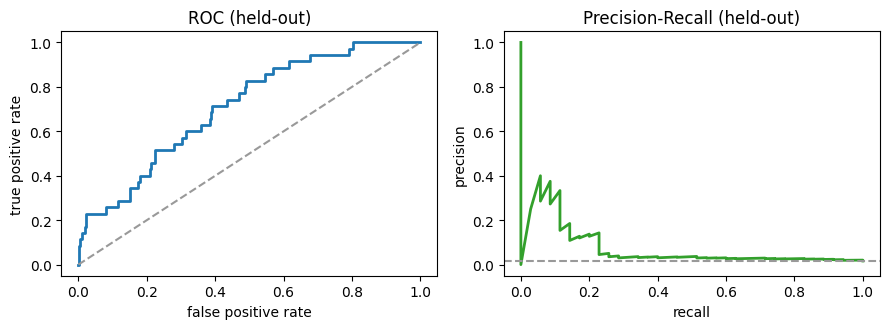

In [6]:
fpr, tpr, _ = roc_curve(yte, p); prec, rec, _ = precision_recall_curve(yte, p)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(fpr, tpr, color='#1f78b4', lw=2); ax[0].plot([0,1],[0,1],'--',color='0.6')
ax[0].set_xlabel('false positive rate'); ax[0].set_ylabel('true positive rate'); ax[0].set_title('ROC (held-out)')
ax[1].plot(rec, prec, color='#33a02c', lw=2); ax[1].axhline(yte.mean(), ls='--', color='0.6')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].set_title('Precision-Recall (held-out)')
plt.tight_layout(); plt.show()

The ROC-AUC looks strong (~0.8), but the **PR-AUC** is far more modest — the honest picture when only 1.6% of
cases are onsets. This is the key evaluation lesson: *on imbalanced data, ROC-AUC flatters a model and
precision-recall tells the truth.*

## Takeaway

This example illustrates **out-of-sample classification with a published regression** and the
**evaluation-metric choice** that matters most for rare events. The Fearon–Laitin logit predicts onset above
chance out of sample, but reporting precision–recall (not accuracy or ROC alone) is what keeps the assessment
honest. (A later example — Gibler–Braithwaite — extends this rare-event setting with tree-based learners.)

## Recommended exercises

1. Replace the single split with stratified 5-fold CV and report mean AUC-PR (the outcome is ~1.6% positive, so use AUC-PR, not accuracy).
2. Fit an L1-penalized logistic regression and compare its AUC-PR and retained variables to the full logit.
3. Plot the calibration (reliability) curve of the predicted probabilities and comment on over/under-confidence.